A frequent point made in discussions of bass speakers is: *Driver size doesn't matter.* This is both agreed upon as a basic truism, and rejected as a myth.

Another frequent point is: *Tens are faster than fifteens because they have smaller cones.* Let's see how that works out.

When confronted with such a controversy, my gut reaction is to figure out what's actually happening under the hood. Perhaps a more precise statement of the myth will turn it into a truism, or maybe vice versa.

I started with a decent-enough design: Eminence 3012HO driver in a box volume equal to the $V_{as}$ parameter.

Next, I looked for an absurdly different driver, but with $F_s$ and $Q_{ts}$ parameters, as close as I could find in the Parts Express catalog. I found the TCP115_4, a 4" driver with a rubber surround. I put it in a box equal to its $V_{as}$ parameter too, and gave each one a 40 Hz port tuning frequency.

For each system, I chose an input power sufficient to reach the excursion limit: 100 Watts for the 12" and 15 Watts for the 4". Now I can begin to make some observations:

1. The excursion and SPL graphs match quite well, except for overall amplitude. Sure, the bigger speaker is louder, but if the two were matched for gain, they'd sound quite close.

2. A small difference at higher frequencies is due to coil inductance, but that's way above the point where the basic electromechanical model is valid anyway.

3. Impedance curves match, no surprise.

4. The step response curves also match, though I had to multiply the 4" curve by 15x to see it on the same plot. *Was this a surprise?* No. Here's the reason. Two speakers with the same frequency response will also have the same transient response. The reason is that frequency and transient response are both governed by the same equation of motion. The smaller cone is lighter, but other parameters had to be changed in order to preserve an acceptable frequency response curve.

What I've done is to make two speakers with radically different cone sizes sound the same (on paper, but it's probably a good prediction for small signals and low frequencies), with the only difference being overall sensitivity.

In [1]:
import pandas as pd
from speakerTheorySympy import *

In [2]:
eminence_3012ho_driver = {
    # Thiele-Small parameters from Eminence DeltaLite 2512-ii driver
    'Znom': 8.0, # Nominal impedance, Ohms
    #'P_e': 250, # Rated power, Watts, we don't use this.
    'f_s': 52, # Resonant frequency, Hz
    R_e: 5.5, # DC resistance, Ohms
    L_e: 0.57*1e-3, # Voice coil inductance, H
    Q_ms: 8.39, # Mechanical Q factor
    Q_es: 0.33, # Electrical Q factor
    V_as: 81.1*1e-3, # Compliance equivalent air volume, m^3
    'X_max': 6.2*1e-3, # Maximum linear excursion, m
    S_d: 532.4*1e-4, # Diaphragm area, m^2
    # Additional physical constants
    rho: 1.2, # Air density, kg/m^3
    c: 343, # Speed of sound, m/s
    # System parameters
    'P_in_rms': 100, # Input power, Watts
    R_ref: 1.0, # Reference distance for SPL calculation, m
    P_ref: 20e-6, # Reference sound pressure for SPL calculation, Pa
}

finish_driver_params(eminence_3012ho_driver)

emi_box = {
    N_d: 1,
    V_box: 81.1*1e-3, # Box volume, liters converted to m^3
    f_port: 40,
    S_port: 21*3.5*1e-4, # Port area, cm*cm converted to m^2
    end_correct: 0.732,
    'Znom': 8,
    'P_in_rms': 100}

emi_system = build_em_params(eminence_3012ho_driver, emi_box)
emi_system  = build_ported_params(emi_system, emi_box[f_port])

In [9]:
tcp115_4_driver = {
    # Thiele-Small parameters from Dayton Audio TCP115-4 driver
    'Znom': 4.0, # Nominal impedance, Ohms
    #'P_e': 40, # Rated power, Watts, we don't use this.
    'f_s': 53.8, # Resonant frequency, Hz
    R_e: 3.2, # DC resistance, Ohms
    L_e: 0.97*1e-3, # Voice coil inductance, H
    Q_ms: 3.14, # Mechanical Q factor
    Q_es: 0.40, # Electrical Q factor
    V_as: 3.1*1e-3, # Compliance equivalent air volume, m^3
    'X_max': 4.0*1e-3, # Maximum linear excursion, m
    S_d: 50.3*1e-4, # Diaphragm area, m^2
    # Additional physical constants
    rho: 1.2, # Air density, kg/m^3
    c: 343, # Speed of sound, m/s
    # System parameters
    'P_in_rms': 20, # Input power, Watts
    R_ref: 1.0, # Reference distance for SPL calculation, m
    P_ref: 20e-6, # Reference sound pressure for SPL calculation, Pa
}

finish_driver_params(tcp115_4_driver)

tcp115_4_box = {
    N_d: 1,
    V_box: 3.1*1e-3, # Box volume, liters converted to m^3
    f_port: 40,
    S_port: 10*3.5*1e-4, # Port area, cm*cm converted to m^2
    end_correct: 0.732,
    'Znom': 4,
    'P_in_rms': 15}

tcp115_4_system = build_em_params(tcp115_4_driver, tcp115_4_box)
tcp115_4_system  = build_ported_params(tcp115_4_system, tcp115_4_box[f_port])

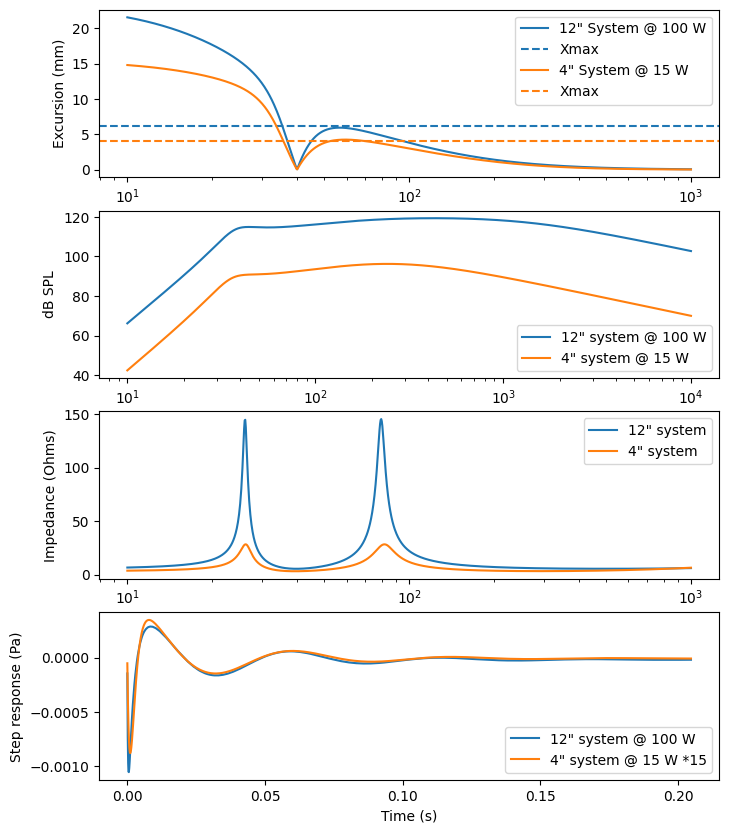

In [10]:
fig, axs = plt.subplots(4, figsize = (8, 10))
excursion_curve(emi_system, axs[0], label = '12" System @ 100 W')
excursion_curve(tcp115_4_system, axs[0], label = '4" System @ 15 W')

sensitivity_curve_ported(emi_system, axs[1], '12" system @ 100 W')
sensitivity_curve_ported(tcp115_4_system, axs[1], '4" system @ 15 W')

impedance_curve(emi_system, axs[2], label = '12" system')
impedance_curve(tcp115_4_system, axs[2], label = '4" system')

transient_response_ported(emi_system, axs[3], label = '12" system @ 100 W')
transient_response_ported(tcp115_4_system, axs[3], mul = 15, label = '4" system @ 15 W')

In [12]:
!jupyter nbconvert --to pdf does_size_matter_sympy.ipynb

[NbConvertApp] Converting notebook does_size_matter_sympy.ipynb to pdf
[NbConvertApp] Support files will be in does_size_matter_sympy_files/
[NbConvertApp] Making directory ./does_size_matter_sympy_files
[NbConvertApp] Writing 33653 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 134186 bytes to does_size_matter_sympy.pdf
